<a href="https://colab.research.google.com/github/ians513/Analisis-de-datos/blob/main/Proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto**
### Karen Oróstica, Alessandro Lavezzi, Nicolás Opazo, Ian Spikin.
## **Variabilidad hospitalaria en la práctica clínica**
### Pregunta principal:
### **¿Los hospitales ubicados en zonas de bajos recursos de la Región Metropolitana absorben sistemáticamente casos de mayor severidad clínica?**

#### Preguntas auxiliares:
- ¿Pacientes con diagnósticos similares reciben procedimientos diferentes dependiendo
del hospital?
- ¿Existe variabilidad hospitalaria en la duración de hospitalización después de controlar
por severidad clínica?
- ¿Algunos hospitales presentan patrones sistemáticos de mayor intervención clínica?
- ¿Cómo se relacionan los lugares más vulnerables con los procedimientos hospitalarios y la duración de hospitalización?
- ¿Cómo se relacionan los lugares más vulnerables con la mortalidad de ciertos diagnósticos?


Datos:
- Egresos hospitalarios – GRD
- Ministerio de Salud de Chile / FONASA
- Índice de Prioridad Social


# Entorno de trabajo

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import IPython.display as display
import sys
np.set_printoptions(threshold=sys.maxsize)
pd.set_option('display.max_columns', None)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
ruta = "/content/drive/MyDrive/Datos Colab/GRD_PUBLICO_2024.txt"

df = pd.read_csv(
    ruta,
    sep="|",
    encoding="latin-1",
    engine="python"
)

In [ ]:
df_copy=df.copy()

In [ ]:
ruta_cie9="/content/drive/MyDrive/Datos Colab/CIE-9 .xlsx"
df_procedimiento = pd.read_excel(ruta_cie9)

In [ ]:
ruta_cie10="/content/drive/MyDrive/Datos Colab/CIE-10.xlsx"
df_diagnostico = pd.read_excel(ruta_cie10)

Tabla maestra para manejar algunas variables:

In [ ]:
ruta_tabla_maestra="/content/drive/MyDrive/Datos Colab/Tablas maestras bases GRD .xlsx"
df_tabla_maestra_pabellon = pd.read_excel(ruta_tabla_maestra,sheet_name="Tipo de Pabellon")
df_tabla_maestra_ir_grd = pd.read_excel(ruta_tabla_maestra,sheet_name="IR - GRD")
df_tabla_maestra_severidad = pd.read_excel(ruta_tabla_maestra,sheet_name="Severidad GRD")
df_tabla_maestra_mortalidad= pd.read_excel(ruta_tabla_maestra,sheet_name="Mortalidad GRD")
df_tabla_maestra_hospitales= pd.read_excel(ruta_tabla_maestra,sheet_name="Hospitales")

# Análisis exploratorio

In [ ]:
df.head(3)

,COD_HOSPITAL,ID_BENEFICIARIO,SEXO,FECHA_NACIMIENTO,ETNIA,PROVINCIA,COMUNA,NACIONALIDAD,PREVISION,SERVICIO_SALUD,TIPO_PROCEDENCIA,TIPO_INGRESO,ESPECIALIDAD_MEDICA,TIPO_ACTIVIDAD,FECHA_INGRESO,SERVICIOINGRESO,FECHATRASLADO1,SERVICIOTRASLADO1,FECHATRASLADO2,SERVICIOTRASLADO2,FECHATRASLADO3,SERVICIOTRASLADO3,FECHATRASLADO4,SERVICIOTRASLADO4,FECHATRASLADO5,SERVICIOTRASLADO5,FECHATRASLADO6,SERVICIOTRASLADO6,FECHATRASLADO7,SERVICIOTRASLADO7,FECHATRASLADO8,SERVICIOTRASLADO8,FECHATRASLADO9,SERVICIOTRASLADO9,FECHAALTA,SERVICIOALTA,TIPOALTA,CONDICIONDEALTANEONATO1,PESORN1,SEXORN1,RN1ESTADO,CONDICIONDEALTANEONATO2,PESORN2,SEXORN2,RN2ESTADO,CONDICIONDEALTANEONATO3,PESORN3,SEXORN3,RN3ESTADO,CONDICIONDEALTANEONATO4,PESORN4,SEXORN4,RN4ESTADO,DIAGNOSTICO1,DIAGNOSTICO2,DIAGNOSTICO3,DIAGNOSTICO4,DIAGNOSTICO5,DIAGNOSTICO6,DIAGNOSTICO7,DIAGNOSTICO8,DIAGNOSTICO9,DIAGNOSTICO10,DIAGNOSTICO11,DIAGNOSTICO12,DIAGNOSTICO13,DIAGNOSTICO14,DIAGNOSTICO15,DIAGNOSTICO16,DIAGNOSTICO17,DIAGNOSTICO18,DIAGNOSTICO19,DIAGNOSTICO20,DIAGNOSTICO21,DIAGNOSTICO22,DIAGNOSTICO23,DIAGNOSTICO24,DIAGNOSTICO25,DIAGNOSTICO26,DIAGNOSTICO27,DIAGNOSTICO28,DIAGNOSTICO29,DIAGNOSTICO30,DIAGNOSTICO31,DIAGNOSTICO32,DIAGNOSTICO33,DIAGNOSTICO34,DIAGNOSTICO35,PROCEDIMIENTO1,PROCEDIMIENTO2,PROCEDIMIENTO3,PROCEDIMIENTO4,PROCEDIMIENTO5,PROCEDIMIENTO6,PROCEDIMIENTO7,PROCEDIMIENTO8,PROCEDIMIENTO9,PROCEDIMIENTO10,PROCEDIMIENTO11,PROCEDIMIENTO12,PROCEDIMIENTO13,PROCEDIMIENTO14,PROCEDIMIENTO15,PROCEDIMIENTO16,PROCEDIMIENTO17,PROCEDIMIENTO18,PROCEDIMIENTO19,PROCEDIMIENTO20,PROCEDIMIENTO21,PROCEDIMIENTO22,PROCEDIMIENTO23,PROCEDIMIENTO24,PROCEDIMIENTO25,PROCEDIMIENTO26,PROCEDIMIENTO27,PROCEDIMIENTO28,PROCEDIMIENTO29,PROCEDIMIENTO30,MEDICOINTERV1_ENCRIPTADO,FECHAPROCEDIMIENTO1,FECHAINTERV1,ESPECIALIDADINTERVENCION,MEDICOALTA_ENCRIPTADO,USOSPABELLON,IR_29301_COD_GRD,IR_29301_PESO,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,HOSPPROCEDENCIA
0,107102,77447810,MUJER,1939-09-18,NINGUNO,MARGA MARGA,VILLA ALEMANA,CHILE,FONASA INSTITUCIONAL - (MAI) B,VIÑA DEL MAR QUILLOTA,"CENTRO ESPECIALIDADES (CDT, CRS, CONSULTORIO A...",PROGRAMADA,OFTALMOLOGÍA,CIRUGÍA MAYOR AMBULATORIA (CMA),2024-03-23,UNIDAD DE RECUPERACIÓN DE PABELLONES (CENTRAL ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23,UNIDAD DE RECUPERACIÓN DE PABELLONES (CENTRAL ...,DOMICILIO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,H26.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.41,13.71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71043147.0,NaN,2024-03-23,OFTALMOLOGÍA,71043147,1.0,022360,"0,4384",0,0,NaN
1,107100,81269680,MUJER,1952-05-31,NINGUNO,VALPARAISO,VIÑA DEL MAR,CHILE,FONASA INSTITUCIONAL - (MAI) D,VIÑA DEL MAR QUILLOTA,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,HEMATOLOGÍA,HOSPITALIZACIÓN,2024-09-26,UNIDAD DE CUIDADOS INTENSIVOS ADULTO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-10-02,UNIDAD DE CUIDADOS INTENSIVOS ADULTO,FALLECIDO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M31.1,R57.2,A41.5,A41.0,R41.8,R56.8,J96.09,N17.9,R41.0,D64.9,R16.1,N28.1,J90,E80.6,D70,D47.3,Z92.4,Z86.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96.72,96.04,99.23,99.07,99.28,99.21,88.01,87.03,89.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,78588090,NaN,041023,"5,8207",3,3,NaN
2,105101,77590791,HOMBRE,2012-07-17,NINGUNO,ELQUI,LA SERENA,CHILE,FONASA INSTITUCIONAL - (MAI) A,COQUIMBO,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,PEDIATRÍA,HOSPITALIZACIÓN,2024-01-22,PEDIATRÍA,2024-01-22,PEDIATRÍA,2024-01-22,PEDIATRÍA,2024-01-22,PEDIATRÍA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-26,PEDIATRÍA,DOMICILIO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,K12.2,K02.9,E66.8,K01.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

Columnas del DataFrame:

In [ ]:
#Mostrar los tipos de datos en el DataFrame
list(df.columns)

['COD_HOSPITAL',
 'ID_BENEFICIARIO',
 'SEXO',
 'FECHA_NACIMIENTO',
 'ETNIA',
 'PROVINCIA',
 'COMUNA',
 'NACIONALIDAD',
 'PREVISION',
 'SERVICIO_SALUD',
 'TIPO_PROCEDENCIA',
 'TIPO_INGRESO',
 'ESPECIALIDAD_MEDICA',
 'TIPO_ACTIVIDAD',
 'FECHA_INGRESO',
 'SERVICIOINGRESO',
 'FECHATRASLADO1',
 'SERVICIOTRASLADO1',
 'FECHATRASLADO2',
 'SERVICIOTRASLADO2',
 'FECHATRASLADO3',
 'SERVICIOTRASLADO3',
 'FECHATRASLADO4',
 'SERVICIOTRASLADO4',
 'FECHATRASLADO5',
 'SERVICIOTRASLADO5',
 'FECHATRASLADO6',
 'SERVICIOTRASLADO6',
 'FECHATRASLADO7',
 'SERVICIOTRASLADO7',
 'FECHATRASLADO8',
 'SERVICIOTRASLADO8',
 'FECHATRASLADO9',
 'SERVICIOTRASLADO9',
 'FECHAALTA',
 'SERVICIOALTA',
 'TIPOALTA',
 'CONDICIONDEALTANEONATO1',
 'PESORN1',
 'SEXORN1',
 'RN1ESTADO',
 'CONDICIONDEALTANEONATO2',
 'PESORN2',
 'SEXORN2',
 'RN2ESTADO',
 'CONDICIONDEALTANEONATO3',
 'PESORN3',
 'SEXORN3',
 'RN3ESTADO',
 'CONDICIONDEALTANEONATO4',
 'PESORN4',
 'SEXORN4',
 'RN4ESTADO',
 'DIAGNOSTICO1',
 'DIAGNOSTICO2',
 'DIAGNOSTICO3',
 

In [ ]:
print("Tipos de datos en el DataFrame:")
df.dtypes.value_counts()

Tipos de datos en el DataFrame:


,count
object,91
float64,36
int64,2


In [ ]:
df.describe()

,COD_HOSPITAL,CONDICIONDEALTANEONATO1,PESORN1,RN1ESTADO,CONDICIONDEALTANEONATO2,PESORN2,RN2ESTADO,CONDICIONDEALTANEONATO3,PESORN3,RN3ESTADO,CONDICIONDEALTANEONATO4,PESORN4,SEXORN4,RN4ESTADO,PROCEDIMIENTO8,PROCEDIMIENTO9,PROCEDIMIENTO11,PROCEDIMIENTO12,PROCEDIMIENTO13,PROCEDIMIENTO14,PROCEDIMIENTO15,PROCEDIMIENTO17,PROCEDIMIENTO18,PROCEDIMIENTO20,PROCEDIMIENTO21,PROCEDIMIENTO22,PROCEDIMIENTO23,PROCEDIMIENTO24,PROCEDIMIENTO25,PROCEDIMIENTO26,PROCEDIMIENTO27,PROCEDIMIENTO28,PROCEDIMIENTO29,PROCEDIMIENTO30,MEDICOINTERV1_ENCRIPTADO,FECHAPROCEDIMIENTO1,MEDICOALTA_ENCRIPTADO,USOSPABELLON
count,1.085813e+06,0.0,119610.000000,97886.000000,0.0,1318.000000,1318.000000,0.0,15.000000,15.000000,0.0,0.0,0.0,0.0,482189.000000,408907.000000,284746.000000,236349.000000,196080.000000,163401.000000,137322.000000,99175.000000,85248.000000,63674.000000,55297.000000,48324.000000,42232.000000,36943.000000,32411.000000,28298.000000,24813.000000,21734.000000,18887.000000,16553.000000,6.182690e+05,0.0,1.085813e+06,655582.000000
mean,1.145584e+05,NaN,3166.208561,9.049905,NaN,2245.728376,8.585736,NaN,1667.533333,7.533333,NaN,NaN,NaN,NaN,89.522418,89.399217,89.042363,88.946015,88.711952,88.657424,88.485398,88.131194,87.952172,88.005153,87.697095,87.877795,87.774355,87.907581,87.922524,87.963993,87.974312,87.867828,88.050296,87.722094,8.187082e+07,NaN,8.332284e+07,1.388478
std,1.079607e+04,NaN,668.376257,1.067824,NaN,628.917866,1.752710,NaN,590.398760,2.559762,NaN,NaN,NaN,NaN,16.111245,16.032193,16.333756,16.376639,16.740058,16.824535,17.129954,17.737122,18.036492,18.032551,18.541461,18.333056,18.409138,18.300269,18.169013,18.164822,18.042320,18.212455,17.823259,18.519460,9.368715e+06,NaN,9.589261e+06,0.863487
min,1.011000e+05,NaN,100.000000,0.000000,NaN,150.000000,0.000000,NaN,100.000000,0.000000,NaN,NaN,NaN,NaN,0.090000,0.010000,0.010000,0.090000,0.010000,0.010000,0.090000,0.090000,0.010000,0.090000,0.090000,0.120000,0.120000,0.120000,0.140000,0.130000,0.090000,0.120000,0.090000,0.120000,6.698964e+07,NaN,6.698964e+07,0.000000
25%,1.091000e+05,NaN,2860.000000,9.000000,NaN,1905.000000,9.000000,NaN,1557.000000,7.500000,NaN,NaN,NaN,NaN,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,7.366486e+07,NaN,7.515274e+07,1.000000
50%,1.141010e+05,NaN,3250.000000,9.000000,NaN,2332.500000,9.000000,NaN,1755.000000,8.000000,NaN,NaN,NaN,NaN,91.390000,91.390000,91.390000,91.390000,91.390000,91.390000,91.390000,91.390000,91.390000,91.390000,91.390000,91.390000,91.390000,91.390000,91.390000,91.390000,91.390000,91.390000,91.330000,91.330000,8.075476e+07,NaN,8.270110e+07,1.000000
75%,1.181050e+05,NaN,3590.000000,9.000000,NaN,2690.000000,9.000000,NaN,2050.000000,9.000000,NaN,NaN,NaN,NaN,99.190000,99.180000,97.690000,96.600000,96.590000,96.590000,96.590000,96.590000,96.570000,96.570000,96.570000,96.560000,96.550000,96.570000,96.390000,96.350000,96.350000,96.350000,96.350000,96.350000,8.763694e+07,NaN,9.167102e+07,1.000000
max,2.007170e+05,NaN,9730.000000,11.000000,NaN,3960.000000,10.000000,NaN,2315.000000,10.000000,NaN,NaN,NaN,NaN,99.990000,99.990000,99.990000,99.990000,99.990000,99.990000,99.990000,99.990000,99.980000,99.980000,99.980000,99.980000,99.980000,99.980000,99.940000,99.980000,99.990000,99.840000,99.980000,99.840000,1.022333e+08,NaN,1.022985e+08,8.000000


# Variables que se eliminarán
En este caso nos interesa la comorbilidad, asi que los diagnósticos secundarios los conservaremos, para poder contemplar los distintos procedimientos clínicos.

Se eliminarán las variables que no otorgan información relevante, además de las que podrían sesgar el estudio:
- Traslado de servicio y fecha de traslado no aportan información, ya que la duración de la hospitalización se puede calcular con el ingreso y el alta.
- Los ID encriptados se eliminnrán, ya que su conservación podría sesgar el estudio a conclusiones intrahospitalarias.
- Las variables que relacionan neonatos se borrarán, ya que en el diagnóstico sale si el paciente llegó con parto múltiple.

In [ ]:
columnas_borrar=['ETNIA','NACIONALIDAD','CONDICIONDEALTANEONATO1','PESORN1','SEXORN1',
 'RN1ESTADO','CONDICIONDEALTANEONATO2','PESORN2','SEXORN2','RN2ESTADO',
 'CONDICIONDEALTANEONATO3','PESORN3','SEXORN3','RN3ESTADO','CONDICIONDEALTANEONATO4',
 'PESORN4','SEXORN4','RN4ESTADO','PREVISION','MEDICOINTERV1_ENCRIPTADO','MEDICOALTA_ENCRIPTADO','ID_BENEFICIARIO',
 'FECHATRASLADO1', 'SERVICIOTRASLADO1', 'FECHATRASLADO2', 'SERVICIOTRASLADO2','FECHATRASLADO3','SERVICIOTRASLADO3',
 'FECHATRASLADO4',  'SERVICIOTRASLADO4', 'FECHATRASLADO5', 'SERVICIOTRASLADO5',
 'FECHATRASLADO6', 'SERVICIOTRASLADO6', 'FECHATRASLADO7', 'SERVICIOTRASLADO7',
 'FECHATRASLADO8', 'SERVICIOTRASLADO8', 'FECHATRASLADO9', 'SERVICIOTRASLADO9', 'COMUNA','PROVINCIA'
]
df = df.drop(columns=columnas_borrar)

Filtrado para tener únicamente la Región Metropolitana:

In [ ]:
servicios_de_interes=["METROPOLITANO SURORIENTE","METROPOLITANO OCCIDENTE","METROPOLITANO SUR","METROPOLITANO CENTRAL","METROPOLITANO ORIENTE","METROPOLITANO NORTE"]
#filtrar por provincias
df = df[df['SERVICIO_SALUD'].isin(servicios_de_interes)]

## Primera pregunta:
- ¿Pacientes con diagnósticos similares reciben procedimientos diferentes dependiendo
del hospital?

In [ ]:
print("DataFrame de procedimientos:")
display.display(df_procedimiento.head())
print("DataFrame de diagnósticos:")
display.display(df_diagnostico.head())
print("DataFrame de tabla maestra - Tipo de Pabellon:")
display.display(df_tabla_maestra_pabellon.head())
print("DataFrame de tabla maestra - IR - GRD:")
display.display(df_tabla_maestra_ir_grd.head())
print("DataFrame de tabla maestra - Severidad GRD:")
display.display(df_tabla_maestra_severidad.head())
print("DataFrame de tabla maestra - Mortalidad GRD:")
display.display(df_tabla_maestra_mortalidad.head())
print("DataFrame de tabla maestra - Hospitales:")
display.display(df_tabla_maestra_hospitales.head())

DataFrame de procedimientos:


,Código,Descripción,Categoría,Sección,Capítulo
0,0.00,PROCEDIMIENTO E INTERVENCION NCOC,"00 PROCEDIMIENTOS E INTERVENCIONES, NO CLASIFI...",00. (00 00) PROCEDIMIENTOS E INTERVENCIONES NO...,00. (00 00) PROCEDIMIENTOS E INTERVENCIONES NO...
1,0.00,ULTRASONIDO TERAPEUTICO,"00 PROCEDIMIENTOS E INTERVENCIONES, NO CLASIFI...",00. (00 00) PROCEDIMIENTOS E INTERVENCIONES NO...,00. (00 00) PROCEDIMIENTOS E INTERVENCIONES NO...
2,0.01,ULTRASONIDO TERAPEUTICO.VASO CABEZA Y CUELLO,"00 PROCEDIMIENTOS E INTERVENCIONES, NO CLASIFI...",00. (00 00) PROCEDIMIENTOS E INTERVENCIONES NO...,00. (00 00) PROCEDIMIENTOS E INTERVENCIONES NO...
3,0.02,ULTRASONIDO TERAPEUTICO.CORAZON,"00 PROCEDIMIENTOS E INTERVENCIONES, NO CLASIFI...",00. (00 00) PROCEDIMIENTOS E INTERVENCIONES NO...,00. (00 00) PROCEDIMIENTOS E INTERVENCIONES NO...
4,0.03,ULTRASONIDO TERAPEUTICO.VASO PERIFERICO,"00 PROCEDIMIENTOS E INTERVENCIONES, NO CLASIFI...",00. (00 00) PROCEDIMIENTOS E INTERVENCIONES NO...,00. (00 00) PROCEDIMIENTOS E INTERVENCIONES NO...


DataFrame de diagnósticos:


,Versión,Código,Descripción,Categoría,Sección,Capítulo
0,CIE-v2013,A00,Cólera,A00 CÓLERA,A00-A09 ENFERMEDADES INFECCIOSAS INTESTINALES,Cap.01 CIERTAS ENFERMEDADES INFECCIOSAS Y PAR...
1,CIE-v2013,A00.0,"Cólera debido a Vibrio cholerae O1, biotipo ch...",A00 CÓLERA,A00-A09 ENFERMEDADES INFECCIOSAS INTESTINALES,Cap.01 CIERTAS ENFERMEDADES INFECCIOSAS Y PAR...
2,CIE-v2013,A00.1,"Cólera debido a Vibrio cholerae O1, biotipo El...",A00 CÓLERA,A00-A09 ENFERMEDADES INFECCIOSAS INTESTINALES,Cap.01 CIERTAS ENFERMEDADES INFECCIOSAS Y PAR...
3,CIE-v2013,A00.9,"Cólera, no especificado",A00 CÓLERA,A00-A09 ENFERMEDADES INFECCIOSAS INTESTINALES,Cap.01 CIERTAS ENFERMEDADES INFECCIOSAS Y PAR...
4,CIE-v2013,A01,Fiebres tifoidea y paratifoidea,A01 FIEBRES TIFOIDEA Y PARATIFOIDEA,A00-A09 ENFERMEDADES INFECCIOSAS INTESTINALES,Cap.01 CIERTAS ENFERMEDADES INFECCIOSAS Y PAR...


DataFrame de tabla maestra - Tipo de Pabellon:


...

,Severidad,Unnamed: 1
0,0,Sin gravedad
1,1,Menor
2,2,Moderada
3,3,Mayor


DataFrame de tabla maestra - Mortalidad GRD:


,Mortalidad,Unnamed: 1
0,0,Sin gravedad
1,1,Menor
2,2,Moderada
3,3,Mayor


DataFrame de tabla maestra - Hospitales:


,HOSPITALES,Unnamed: 1
0,101100,Hospital Dr. Juan Noé Crevanni (Arica)
1,101203,Clínica Hebe
2,101212,Clínica San Agustín
3,101213,Clínica San José
4,101215,Complejo Penitenciario


In [ ]:
#df['IR_29301_COD_GRD'] = df['IR_29301_COD_GRD'].astype(str).str.strip()
df_tabla_maestra_ir_grd['IR- GRD'] = df_tabla_maestra_ir_grd['IR- GRD'].astype(str).str.strip()
df['IR_29301_COD_GRD'] = pd.to_numeric(df['IR_29301_COD_GRD'], errors='coerce').fillna(-1).astype(int).astype(str)
df=pd.merge(df,df_tabla_maestra_ir_grd,left_on="IR_29301_COD_GRD",right_on="IR- GRD",how="left")
df.drop(columns=['IR- GRD','IR_29301_COD_GRD'], inplace=True)
df = df.rename(columns={'Unnamed: 1': 'GRD'})
#df

In [ ]:
df['IR_29301_SEVERIDAD'] = df['IR_29301_SEVERIDAD'].astype(str).str.strip()
df_tabla_maestra_severidad['Severidad'] = df_tabla_maestra_severidad['Severidad'].astype(str).str.strip()
df['IR_29301_SEVERIDAD'] = pd.to_numeric(df['IR_29301_SEVERIDAD'], errors='coerce').fillna(-1).astype(int).astype(str)
df=pd.merge(df,df_tabla_maestra_severidad,left_on="IR_29301_SEVERIDAD",right_on="Severidad",how="left")
df.drop(columns=['IR_29301_SEVERIDAD','Severidad'], inplace=True)
df = df.rename(columns={'Unnamed: 1': 'SEVERIDAD'})
#df

In [ ]:
df['IR_29301_MORTALIDAD'] = df['IR_29301_MORTALIDAD'].astype(str).str.strip()
df_tabla_maestra_mortalidad['Mortalidad'] = df_tabla_maestra_mortalidad['Mortalidad'].astype(str).str.strip()
df['IR_29301_MORTALIDAD'] = pd.to_numeric(df['IR_29301_MORTALIDAD'], errors='coerce').fillna(-1).astype(int).astype(str)
df=pd.merge(df,df_tabla_maestra_mortalidad,left_on="IR_29301_MORTALIDAD",right_on="Mortalidad",how="left")
df.drop(columns=['IR_29301_MORTALIDAD','Mortalidad'], inplace=True)
df = df.rename(columns={'Unnamed: 1': 'MORTALIDAD'})
#df

In [ ]:
df['COD_HOSPITAL'] = df['COD_HOSPITAL'].astype(str).str.strip()
df_tabla_maestra_hospitales['HOSPITALES'] = df_tabla_maestra_hospitales['HOSPITALES'].astype(str).str.strip()
df['COD_HOSPITAL'] = pd.to_numeric(df['COD_HOSPITAL'], errors='coerce').fillna(-1).astype(int).astype(str)
df=pd.merge(df,df_tabla_maestra_hospitales,left_on="COD_HOSPITAL",right_on="HOSPITALES",how="left")
df.drop(columns=['COD_HOSPITAL','HOSPITALES'], inplace=True)
df = df.rename(columns={'Unnamed: 1': 'HOSPITAL'})
#df

In [ ]:
df.head()

,SEXO,FECHA_NACIMIENTO,SERVICIO_SALUD,TIPO_PROCEDENCIA,TIPO_INGRESO,ESPECIALIDAD_MEDICA,TIPO_ACTIVIDAD,FECHA_INGRESO,SERVICIOINGRESO,FECHAALTA,SERVICIOALTA,TIPOALTA,DIAGNOSTICO1,DIAGNOSTICO2,DIAGNOSTICO3,DIAGNOSTICO4,DIAGNOSTICO5,DIAGNOSTICO6,DIAGNOSTICO7,DIAGNOSTICO8,DIAGNOSTICO9,DIAGNOSTICO10,DIAGNOSTICO11,DIAGNOSTICO12,DIAGNOSTICO13,DIAGNOSTICO14,DIAGNOSTICO15,DIAGNOSTICO16,DIAGNOSTICO17,DIAGNOSTICO18,DIAGNOSTICO19,DIAGNOSTICO20,DIAGNOSTICO21,DIAGNOSTICO22,DIAGNOSTICO23,DIAGNOSTICO24,DIAGNOSTICO25,DIAGNOSTICO26,DIAGNOSTICO27,DIAGNOSTICO28,DIAGNOSTICO29,DIAGNOSTICO30,DIAGNOSTICO31,DIAGNOSTICO32,DIAGNOSTICO33,DIAGNOSTICO34,DIAGNOSTICO35,PROCEDIMIENTO1,PROCEDIMIENTO2,PROCEDIMIENTO3,PROCEDIMIENTO4,PROCEDIMIENTO5,PROCEDIMIENTO6,PROCEDIMIENTO7,PROCEDIMIENTO8,PROCEDIMIENTO9,PROCEDIMIENTO10,PROCEDIMIENTO11,PROCEDIMIENTO12,PROCEDIMIENTO13,PROCEDIMIENTO14,PROCEDIMIENTO15,PROCEDIMIENTO16,PROCEDIMIENTO17,PROCEDIMIENTO18,PROCEDIMIENTO19,PROCEDIMIENTO20,PROCEDIMIENTO21,PROCEDIMIENTO22,PROCEDIMIENTO23,PROCEDIMIENTO24,PROCEDIMIENTO25,PROCEDIMIENTO26,PROCEDIMIENTO27,PROCEDIMIENTO28,PROCEDIMIENTO29,PROCEDIMIENTO30,FECHAPROCEDIMIENTO1,FECHAINTERV1,ESPECIALIDADINTERVENCION,USOSPABELLON,IR_29301_PESO,HOSPPROCEDENCIA,GRD,SEVERIDAD,MORTALIDAD,HOSPITAL
0,HOMBRE,1952-11-03,METROPOLITANO ORIENTE,"CENTRO ESPECIALIDADES (CDT, CRS, CONSULTORIO A...",PROGRAMADA,UROLOGÍA,HOSPITALIZACIÓN,2024-04-08,AREA MEDICO-QUIRURGICO CUIDADOS MEDIOS,2024-04-14,AREA MEDICO-QUIRURGICO CUIDADOS MEDIOS,DOMICILIO,C61,K63.1,K66.0,E66.9,Z53.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.33,54.59,45.91,99.21,99.29,93.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-04-08,UROLOGÍA,1.0,"3,5647",NaN,PH PROCEDIMIENTOS COMPLEJOS DEL TRACTO DIGESTI...,Mayor,Mayor,"Hospital Del Salvador (Santiago, Providencia)"
1,MUJER,1930-03-28,METROPOLITANO ORIENTE,OTROS HOSPITALES DE LA RED,URGENCIA,TRAUMATOLOGÍA Y ORTOPEDIA,HOSPITALIZACIÓN,2024-08-09,AREA MEDICO-QUIRURGICO CUIDADOS MEDIOS,2024-08-17,AREA MEDICO-QUIRURGICO CUIDADOS MEDIOS,DOMICILIO,S72.10,W01.04,I10,G20,F31.9,Z59.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,79.15,93.01,93.12,93.18,99.19,99.29,88.26,89.52,90.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-08-13,TRAUMATOLOGÍA Y ORTOPEDIA,1.0,"1,4691","HOSPITAL DR. LUIS TISNÉ B. (SANTIAGO, PEÑALOLÉN)",PH PROCEDIMIENTOS SOBRE FÉMUR Y CADERA EXCEPTO...,Moderada,Moderada,"Hospital Del Salvador (Santiago, Providencia)"
2,HOMBRE,1958-08-25,METROPOLITANO ORIENTE,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,CIRUGÍA GENERAL,HOSPITALIZACIÓN,2024-09-27,AREA QUIRÚRGICA,2024-10-16,AREA QUIRÚRGICA,DOMICILIO,T29.2,X12.84,T31.0,E11.9,I10,I87.2,E66.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86.63,86.22,99.21,99.29,93.12,93.18,91.53,91.56,91.59,89.52,99.21,93.17,93.18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DESCONOCIDA,CIRUGÍA GENERAL,1.0,"2,0678",NaN,PH INJERTO DE PIEL CON QUEMADURA W/CC,Moderada,Moderada,"Hospital Del Salvador (Santiago, Providencia)"
3,HOMBRE,2000-02-18,METROPOLITANO ORIENTE,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,MEDICINA INTERNA,HOSPITALIZACIÓN,2024-10-16,UNIDAD DE CUIDADOS INTENSIVOS ADULTO,2024-11-15,UNIDAD DE TRATAMIENTO INTERMEDIO MEDICINA ADULTO,DOMICILIO,K72.0,K72.1,G61.0,E83.4,K70.1,N17.9,D68.9,K85.9,B25.9,K76.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.59,00.91,96.72,96.04,99.05,89.61,38.93,96.08,99.04,99.07,88.76,88.01,88.72,39.95,93.18,93.12,93.75,99.21,00.17,99.29,99.23,3.31,90.53,91.39,91.33,93.08,90.09,90.06,90.03,88.97,NaN,2024-10-18,CIRUGÍA GENERAL,1.0,"13,467",NaN,PH TRASPLANTE HEPÁTICO W/MCC,Mayor,Mayor,"Hospital Del Salvador (Santiago, Providencia)

In [ ]:
# @title
# Normalizamos el maestro de procedimientos
df_procedimiento['Código'] = df_procedimiento['Código'].astype(str).str.strip()
dict_proc = df_procedimiento.set_index('Código')['Descripción'].to_dict()

# Normalizamos el maestro de diagnósticos (por si acaso)
df_diagnostico['Código'] = df_diagnostico['Código'].astype(str).str.strip()
dict_diag = df_diagnostico.set_index('Código')['Descripción'].to_dict()


In [ ]:
# @title
cols_diag = [f'DIAGNOSTICO{i}' for i in range(1, 35 + 1)]
cols_proc = [f'PROCEDIMIENTO{i}' for i in range(1, 30 + 1)]

In [ ]:
# @title
# Mapeo de Diagnósticos
for col in cols_diag:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().map(dict_diag)

# Mapeo de Procedimientos
for col in cols_proc:
    if col in df.columns:
        # Importante: Algunos códigos como '13.40' pueden leerse como '13.4'
        # Si esto pasa, podrías necesitar redondear o formatear antes.
        df[col] = df[col].astype(str).str.strip().map(dict_proc)


In [ ]:
df.head(3)

,SEXO,FECHA_NACIMIENTO,SERVICIO_SALUD,TIPO_PROCEDENCIA,TIPO_INGRESO,ESPECIALIDAD_MEDICA,TIPO_ACTIVIDAD,FECHA_INGRESO,SERVICIOINGRESO,FECHAALTA,SERVICIOALTA,TIPOALTA,DIAGNOSTICO1,DIAGNOSTICO2,DIAGNOSTICO3,DIAGNOSTICO4,DIAGNOSTICO5,DIAGNOSTICO6,DIAGNOSTICO7,DIAGNOSTICO8,DIAGNOSTICO9,DIAGNOSTICO10,DIAGNOSTICO11,DIAGNOSTICO12,DIAGNOSTICO13,DIAGNOSTICO14,DIAGNOSTICO15,DIAGNOSTICO16,DIAGNOSTICO17,DIAGNOSTICO18,DIAGNOSTICO19,DIAGNOSTICO20,DIAGNOSTICO21,DIAGNOSTICO22,DIAGNOSTICO23,DIAGNOSTICO24,DIAGNOSTICO25,DIAGNOSTICO26,DIAGNOSTICO27,DIAGNOSTICO28,DIAGNOSTICO29,DIAGNOSTICO30,DIAGNOSTICO31,DIAGNOSTICO32,DIAGNOSTICO33,DIAGNOSTICO34,DIAGNOSTICO35,PROCEDIMIENTO1,PROCEDIMIENTO2,PROCEDIMIENTO3,PROCEDIMIENTO4,PROCEDIMIENTO5,PROCEDIMIENTO6,PROCEDIMIENTO7,PROCEDIMIENTO8,PROCEDIMIENTO9,PROCEDIMIENTO10,PROCEDIMIENTO11,PROCEDIMIENTO12,PROCEDIMIENTO13,PROCEDIMIENTO14,PROCEDIMIENTO15,PROCEDIMIENTO16,PROCEDIMIENTO17,PROCEDIMIENTO18,PROCEDIMIENTO19,PROCEDIMIENTO20,PROCEDIMIENTO21,PROCEDIMIENTO22,PROCEDIMIENTO23,PROCEDIMIENTO24,PROCEDIMIENTO25,PROCEDIMIENTO26,PROCEDIMIENTO27,PROCEDIMIENTO28,PROCEDIMIENTO29,PROCEDIMIENTO30,FECHAPROCEDIMIENTO1,FECHAINTERV1,ESPECIALIDADINTERVENCION,USOSPABELLON,IR_29301_PESO,HOSPPROCEDENCIA,GRD,SEVERIDAD,MORTALIDAD,HOSPITAL
0,HOMBRE,1952-11-03,METROPOLITANO ORIENTE,"CENTRO ESPECIALIDADES (CDT, CRS, CONSULTORIO A...",PROGRAMADA,UROLOGÍA,HOSPITALIZACIÓN,2024-04-08,AREA MEDICO-QUIRURGICO CUIDADOS MEDIOS,2024-04-14,AREA MEDICO-QUIRURGICO CUIDADOS MEDIOS,DOMICILIO,Tumor maligno de la próstata,Perforación del intestino (no traumática),Adherencias peritoneales,"Obesidad, no especificada",Procedimiento no realizado por contraindicación,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ESCISION INTESTINO DELGADO LOCAL SALVO DUODENO,LISIS ADHERENCIA PERITONEO.OTRA,ANASTOMOSIS INTESTINO DELGADO A INTESTINO DELGADO,INYECCION ANTIBIOTICO,INYECCION SUSTANCIA TERAPEUTICA O PROFILACTICA...,EJERCICIO ACTIVO MUSCULOESQUELETICO OTRO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-04-08,UROLOGÍA,1.0,"3,5647",NaN,PH PROCEDIMIENTOS COMPLEJOS DEL TRACTO DIGESTI...,Mayor,Mayor,"Hospital Del Salvador (Santiago, Providencia)"
1,MUJER,1930-03-28,METROPOLITANO ORIENTE,OTROS HOSPITALES DE LA RED,URGENCIA,TRAUMATOLOGÍA Y ORTOPEDIA,HOSPITALIZACIÓN,2024-08-09,AREA MEDICO-QUIRURGICO CUIDADOS MEDIOS,2024-08-17,AREA MEDICO-QUIRURGICO CUIDADOS MEDIOS,DOMICILIO,"Fractura pertrocanteriana, cerrada","Caída en el mismo nivel por deslizamiento, tro...",Hipertensión esencial (primaria),Enfermedad de Parkinson,"Trastorno afectivo bipolar, no especificado",Problemas relacionados con persona que reside ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,REDUCCION CERRADA FRACTURA FEMUR CON FIJACION ...,EVALUACION FUNCIONAL,EJERCICIO ACTIVO MUSCULOESQUELETICO OTRO,EJERCICIO RESPIRATORIO,INYECCION ANTICOAGULANTE,INYECCION SUSTANCIA TERAPEUTICA O PROFILACTICA...,RADIOGRAFIA HUESO PELVIS Y CADERA OTRA,ELECTROCARDIOGRAFIA,EXAMEN MICROSCOPICO SANGRE.OTRO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-08-13,TRAUMATOLOGÍA Y ORTOPEDIA,1.0,"1,4691","HOSPITAL DR. LUIS TISNÉ B. (SANTIAGO, PEÑALOLÉN)",PH PROCEDIMIENTOS SOBRE FÉMUR Y CADERA EXCEPTO...,Moderada,Moderada,"Hospital Del Salvador (Santiago, Providencia)"
2,HOMBRE,1958-08-25,METROPOLITANO ORIENTE,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,CIRUGÍA GENERAL,HOSPITALIZACIÓN,2024-09-27,AREA QUIRÚRGICA,2024-10-16,AREA QUIRÚRGICA,DOMICILIO,"Quemaduras de múltiples regiones, mencionadas ...","Contacto con otros líquidos calientes, otro lu...",Quemaduras que afectan menos del 10% de la sup...,Diabetes mellitus tipo 2 sin complicaciones,Hipertensión esencial (primaria),Insuficiencia venosa (crónica) (periférica),Obesidad debida a exceso de calorías,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

# Índices útiles

- Índice de Casuística:
$$CMI_h = \frac{\sum_{i=1}^{n} (W_{i,h} \times D_{i,h})}{N_h}$$
Donde $W_{i,h}$ es el peso relativo preestablecido a nivel nacional para el Grupo Relacionado por el Diagnóstico $i$ atendido en el hospital $h$; $D_{i,h}$ es el número total de altas (descargas) de pacientes clasificados bajo ese GRD $i$; y $N_h$ es el volumen total de altas del hospital en dicho periodo.

- Índice de Prioridad Social: Ministerio de Desarrollo Social y Familia

$$Complejidad\ Social\ Ajustada\ (C_{SA\_h}) = CMI_h \times \left( \frac{ALOS_h}{\overline{ALOS_{nacional}}} \right) \times \gamma (IPS_h)$$

ALOOOO

# Visualizaciones iniciales de apoyo

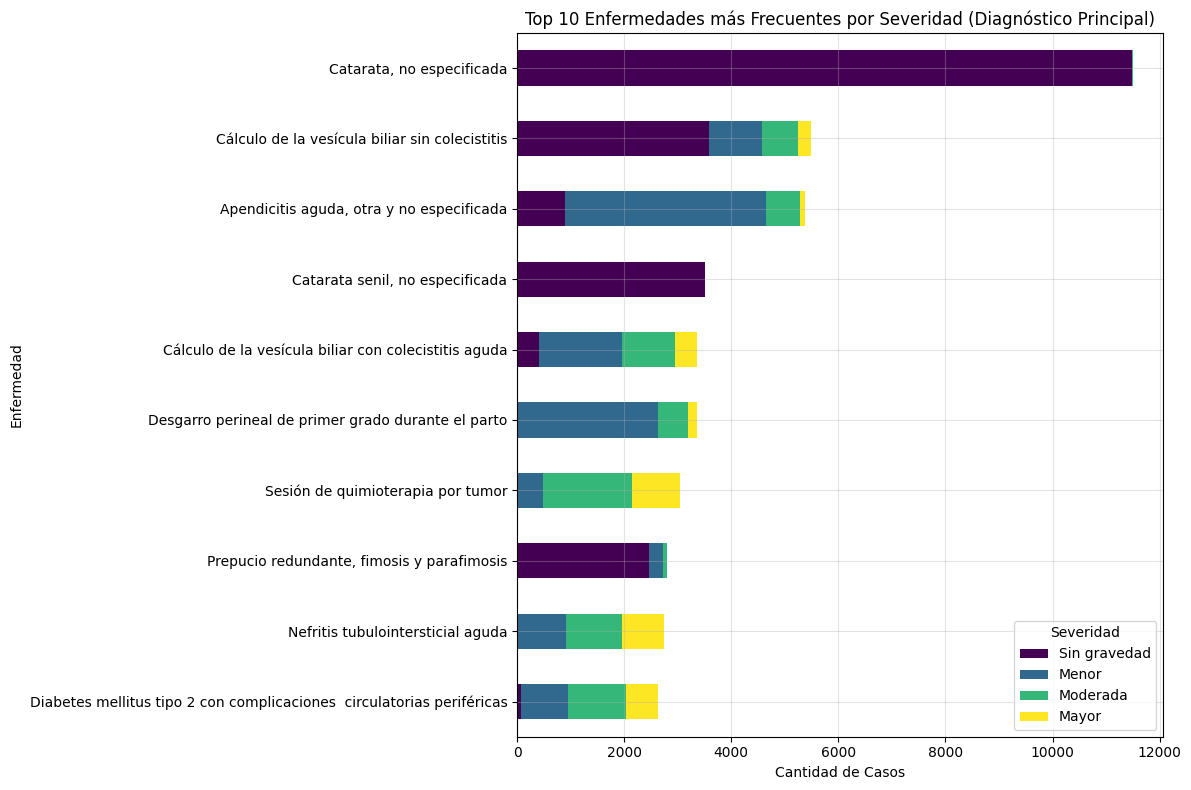

In [ ]:
# @title
top_diagnoses = (
    df['DIAGNOSTICO1']
    .dropna()
    .astype(str)
    .str.strip()
)

top_diagnoses = top_diagnoses[top_diagnoses != ""]
top_diagnoses = top_diagnoses[top_diagnoses.str.lower() != "nan"]
top_diagnoses = top_diagnoses.value_counts().head(10).index

# Filter the DataFrame to include only these top diagnoses
df_top_diagnoses = df[df['DIAGNOSTICO1'].isin(top_diagnoses)].copy()

# Group by DIAGNOSTICO1 and SEVERIDAD, then count
df_diag_severity = df_top_diagnoses.groupby(['DIAGNOSTICO1', 'SEVERIDAD']).size().unstack(fill_value=0)

# Ensure severity order for plotting
orden_severidad = ['Sin gravedad', 'Menor', 'Moderada', 'Mayor']
# Reindex to ensure all severity columns exist and are in order
df_diag_severity = df_diag_severity.reindex(columns=orden_severidad, fill_value=0)

# Calculate total cases for each diagnosis and sort
df_diag_severity['Total'] = df_diag_severity.sum(axis=1)
df_diag_severity = df_diag_severity.sort_values(by='Total', ascending=True).drop(columns='Total')

# Plotting as a horizontal stacked bar chart
fig, ax = plt.subplots(figsize=(12, 8))
df_diag_severity.plot(kind='barh', stacked=True, ax=ax, cmap='viridis')

plt.title('Top 10 Enfermedades más Frecuentes por Severidad (Diagnóstico Principal)')
plt.xlabel('Cantidad de Casos')
plt.ylabel('Enfermedad')
plt.legend(title='Severidad')
plt.tight_layout()
plt.grid(alpha=0.35)
plt.show()

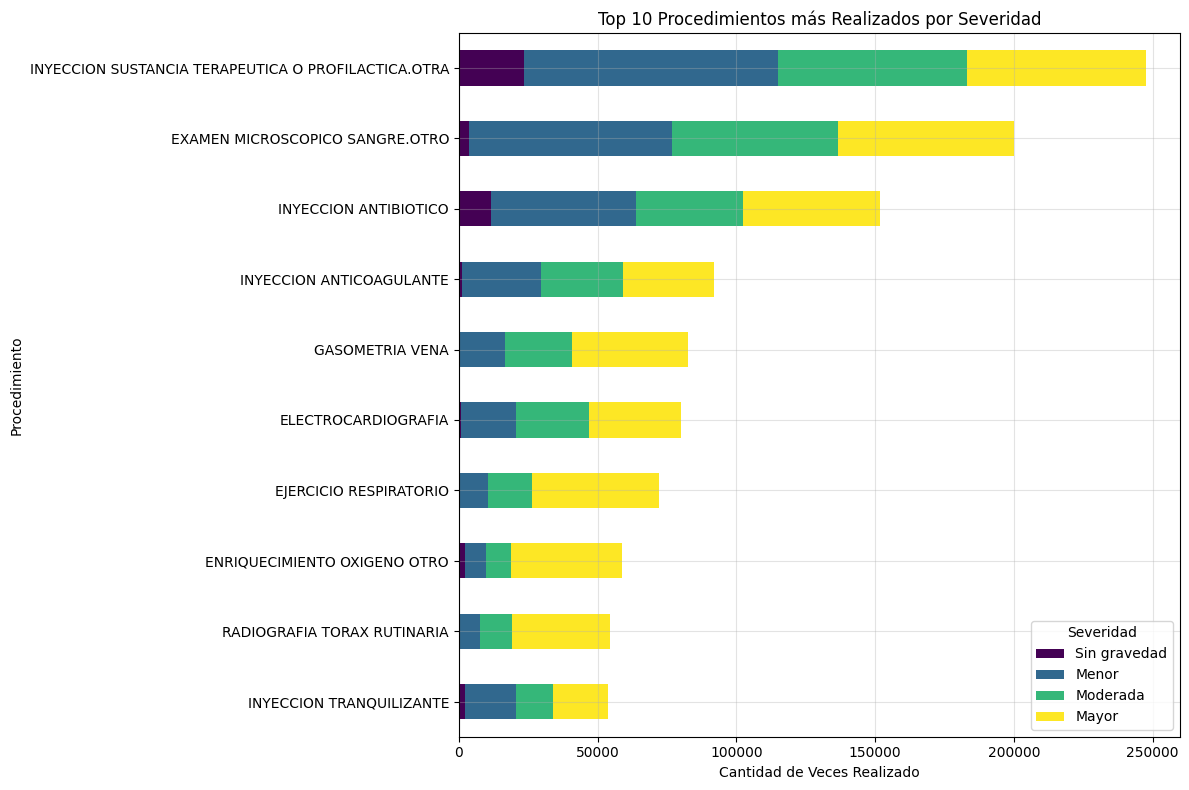

In [ ]:
# @title
# Columnas de procedimientos (ajusta el rango si tienes más o menos)
cols_proc = [f'PROCEDIMIENTO{i}' for i in range(1, 30 + 1)]

# Filtrar solo las columnas que existen en el df
cols_proc_existentes = [col for col in cols_proc if col in df.columns]

# Create a temporary DataFrame for all procedures and their severities
procedure_severity_list = []
for col in cols_proc_existentes:
    # Only include non-null procedures and their corresponding severity
    temp_df = df[[col, 'SEVERIDAD']].dropna(subset=[col]).copy()
    temp_df = temp_df[temp_df[col].astype(str).str.strip() != ""]
    temp_df = temp_df[temp_df[col].astype(str).str.lower() != "nan"]
    temp_df.columns = ['PROCEDIMIENTO', 'SEVERIDAD']
    procedure_severity_list.append(temp_df)

df_procedures_long = pd.concat(procedure_severity_list, ignore_index=True)

# Get the top 10 most frequent procedures
top_procedures = df_procedures_long['PROCEDIMIENTO'].value_counts().head(10).index

# Filter the long format DataFrame to include only these top procedures
df_top_procedures_filtered = df_procedures_long[df_procedures_long['PROCEDIMIENTO'].isin(top_procedures)]

# Group by PROCEDURE and SEVERIDAD, then count
df_proc_severity = df_top_procedures_filtered.groupby(['PROCEDIMIENTO', 'SEVERIDAD']).size().unstack(fill_value=0)

# Ensure severity order for plotting
orden_severidad = ['Sin gravedad', 'Menor', 'Moderada', 'Mayor']
# Reindex to ensure all severity columns exist and are in order
df_proc_severity = df_proc_severity.reindex(columns=orden_severidad, fill_value=0)

# Calculate total cases for each procedure and sort
df_proc_severity['Total'] = df_proc_severity.sum(axis=1)
df_proc_severity = df_proc_severity.sort_values(by='Total', ascending=True).drop(columns='Total')

# Plotting as a horizontal stacked bar chart
fig, ax = plt.subplots(figsize=(12, 8))
df_proc_severity.plot(kind='barh', stacked=True, ax=ax, cmap='viridis')

plt.title('Top 10 Procedimientos más Realizados por Severidad')
plt.xlabel('Cantidad de Veces Realizado')
plt.ylabel('Procedimiento')
plt.legend(title='Severidad')
plt.tight_layout()
plt.grid(alpha=0.35)
plt.show()

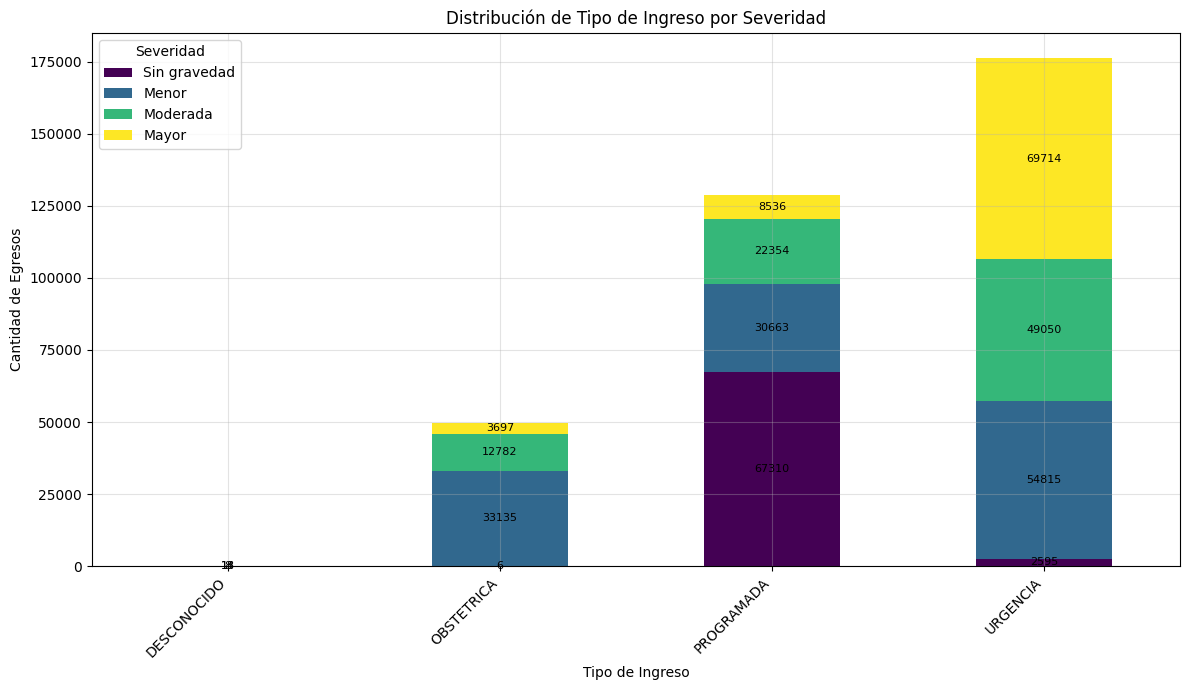

In [ ]:
# @title
plt.figure(figsize=(10, 7))

# Agrupar por TIPO_INGRESO y SEVERIDAD
df_grouped = df.groupby(['TIPO_INGRESO', 'SEVERIDAD']).size().unstack(fill_value=0)

# Asegurarse de que la severidad esté en el orden correcto para el apilamiento
orden_severidad = ['Sin gravedad', 'Menor', 'Moderada', 'Mayor']
df_grouped = df_grouped[orden_severidad]

# Crear el gráfico de barras apiladas
ax = df_grouped.plot(kind='bar', stacked=True, figsize=(12, 7), cmap='viridis', ax=plt.gca())

plt.title('Distribución de Tipo de Ingreso por Severidad')
plt.xlabel('Tipo de Ingreso')
plt.ylabel('Cantidad de Egresos')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Severidad')

# Añadir los números a cada barra
for container in ax.containers:
    for patch in container.patches:
        width = patch.get_width()
        height = patch.get_height()
        x, y = patch.get_xy()
        # Solo si el valor es mayor que 0, para evitar etiquetas en segmentos vacíos
        if height > 0:
            ax.text(x + width/2, y + height/2, f'{int(height)}',
                    ha='center', va='center', color='black', fontsize=8)

plt.tight_layout()
plt.grid(alpha=0.35)
plt.show()

### Tipo de Actividad Hospitalaria por Severidad

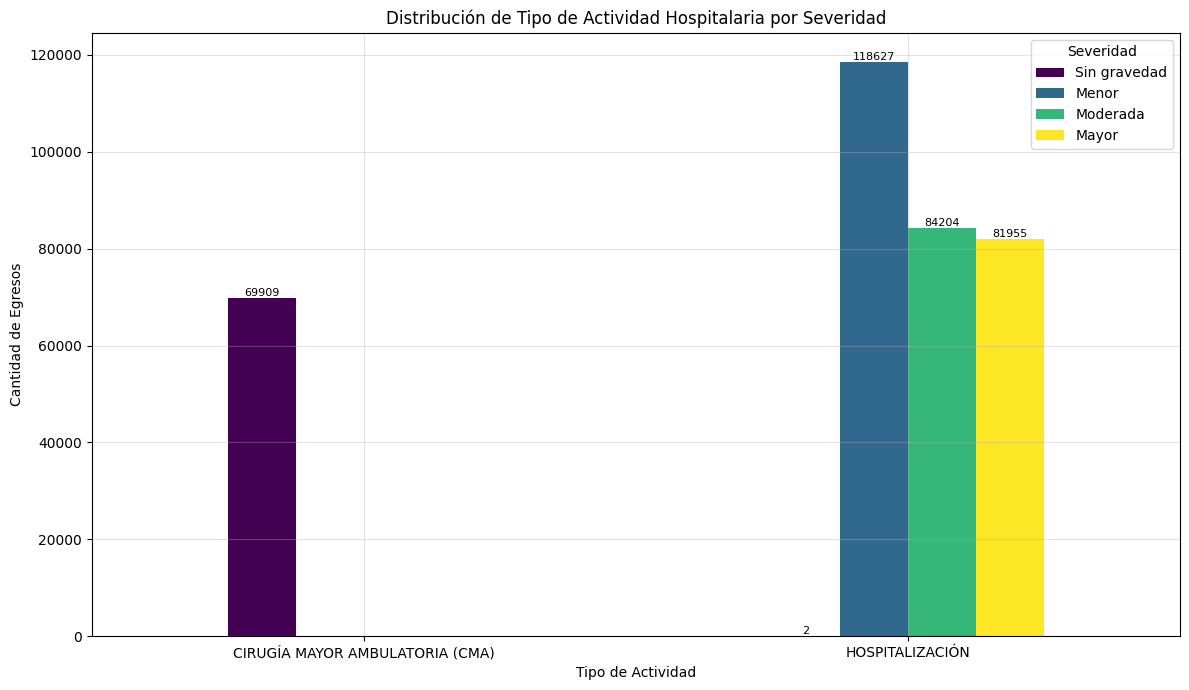

In [ ]:
# @title
plt.figure(figsize=(12, 7))

# Agrupar por TIPO_ACTIVIDAD y SEVERIDAD
df_activity_severity = df.groupby(['TIPO_ACTIVIDAD', 'SEVERIDAD']).size().unstack(fill_value=0)

# Asegurarse de que la severidad esté en el orden correcto
orden_severidad = ['Sin gravedad', 'Menor', 'Moderada', 'Mayor']
df_activity_severity = df_activity_severity[orden_severidad]

# Crear el gráfico de barras agrupadas
ax = df_activity_severity.plot(kind='bar', figsize=(12, 7), cmap='viridis', ax=plt.gca())

plt.title('Distribución de Tipo de Actividad Hospitalaria por Severidad')
plt.xlabel('Tipo de Actividad')
plt.ylabel('Cantidad de Egresos')
plt.xticks(rotation=0, ha='center')
plt.legend(title='Severidad')

# Añadir los números a cada barra
for container in ax.containers:
    for patch in container.patches:
        width = patch.get_width()
        height = patch.get_height()
        x, y = patch.get_xy()
        if height > 0:
            ax.text(x + width/2, y + height, f'{int(height)}',
                    ha='center', va='bottom', color='black', fontsize=8)

plt.tight_layout()
plt.grid(alpha=0.35)
plt.show()

# Análisis de Severidad por Sexo en la Región Metropolitana

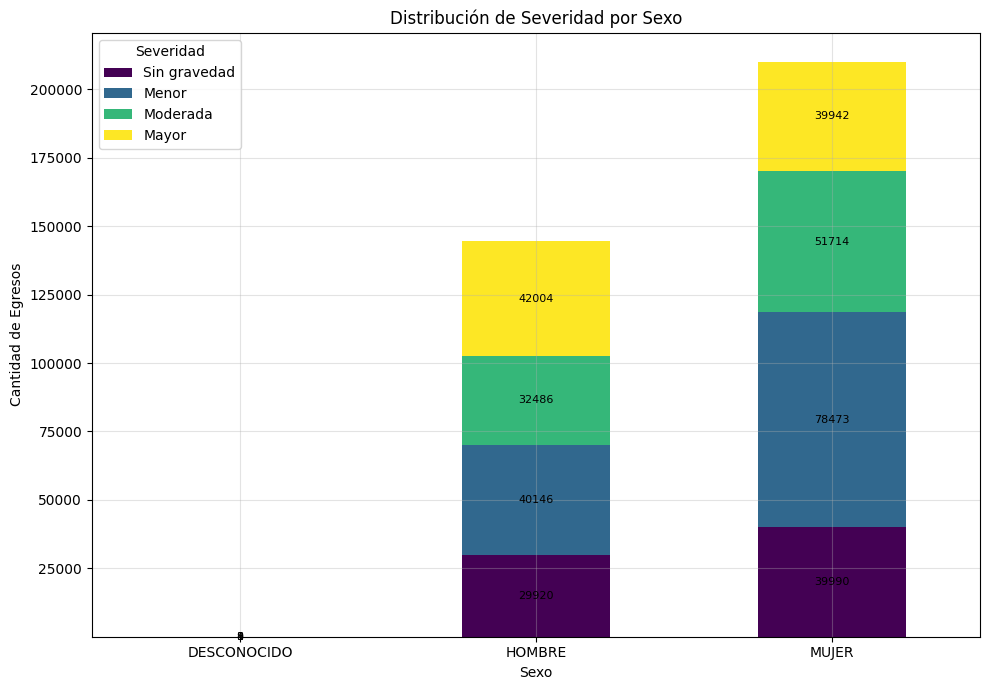

In [ ]:
# @title
# Agrupar por SEXO y SEVERIDAD
df_sex_severity = df.groupby(['SEXO', 'SEVERIDAD']).size().unstack(fill_value=0)

# Asegurarse de que la severidad esté en el orden correcto para el apilamiento
orden_severidad = ['Sin gravedad', 'Menor', 'Moderada', 'Mayor']
df_sex_severity = df_sex_severity.reindex(columns=orden_severidad, fill_value=0)

# Crear el gráfico de barras apiladas
fig, ax = plt.subplots(figsize=(10, 7))
df_sex_severity.plot(kind='bar', stacked=True, cmap='viridis', ax=ax)

plt.title('Distribución de Severidad por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Cantidad de Egresos')
plt.xticks(rotation=0)
plt.legend(title='Severidad')

# Añadir los números a cada barra
for container in ax.containers:
    for patch in container.patches:
        width = patch.get_width()
        height = patch.get_height()
        x, y = patch.get_xy()
        # Solo si el valor es mayor que 0, para evitar etiquetas en segmentos vacíos
        if height > 0:
            ax.text(x + width/2, y + height/2, f'{int(height)}', ha='center', va='center', color='black', fontsize=8)

plt.tight_layout()
plt.grid(alpha=0.35)
plt.show()

In [ ]:
df["HOSPITAL"].value_counts()

,count
HOSPITAL,
"Complejo Hospitalario Dr. Sótero del Río (Santiago, Puente Alto)",49409
"Complejo Hospitalario San José (Santiago, Independencia)",26884
"Hospital Barros Luco Trudeau (Santiago, San Miguel)",26797
"Hospital San Juan de Dios (Santiago, Santiago)",26240
"Hospital Dr. Félix Bulnes Cerda (Santiago, Quinta Normal)",25744
Hospital Padre Alberto Hurtado (San Ramón),20820
Hospital Clínico Metropolitano El Carmen Doctor Luis Valentín Ferrada,20306
Hospital Clínico Metropolitano La Florida Dra. Eloisa Díaz Inzunza,20041
"Hospital Clínico San Borja-Arriarán (Santiago, Santiago)",19678


### Cálculo del Índice de Casuística (CMI) por Hospital